## Create Oprimization Baselines for Sales Volume & Price

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

def load_data(file_path):
    """Load data from a xlsx file"""
    return pd.read_excel(file_path)

PATH_FILE = '/Users/nathandouieb/Desktop/FinalProjectV3/data/processed/data_cleaned.xlsx'
data = load_data(file_path = PATH_FILE)

data_modelling = data[data.Promotion == 0][['WEEK', 'PRICE', 'MOVE']]
print(data_modelling.shape)
data_modelling.head(3)

(205, 3)


,WEEK,PRICE,MOVE
0,1,1.79,50
1,2,1.79,32
2,3,1.79,48


### 1.1 Detect Outliers using IQR Method

To prevent distortion in the baseline estimate due to outlier observations, and to ensure a faithful representation of the demand pattern, extreme values ​​were removed using the IQR statistical method.

* **Interquartile Range (IQR):**
    $$IQR = Q_3 - Q_1$$

* **Lower Control Limit (LCL) :**
    $$\text{Lower Bound} = Q_1 - 1.5 \times IQR$$

* **Upper Control Limit (UCL):**
    $$\text{Upper Bound} = Q_3 + 1.5 \times IQR$$

In [2]:
def iqr(column:str, k:float = 1.5, print_limits: bool = False) -> float:
    '''
    Detect Outliers using IQR method
    Arg:
        column: str -> column name 
        k: float -> Scale Factor
    Return:
        lower: float -> LCL
        upper: float -> UCL

    '''
    # IQR Test
    Q1 = data_modelling[column].quantile(0.25)
    Q3 = data_modelling[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - k * IQR
    upper = Q3 + k * IQR

    if print_limits:
        print(f'Upper: {upper}')
        print(f'Lower: {lower}')

    return lower, upper

### 2. Baseline for Sales

Upper: 109.0
Lower: -11.0


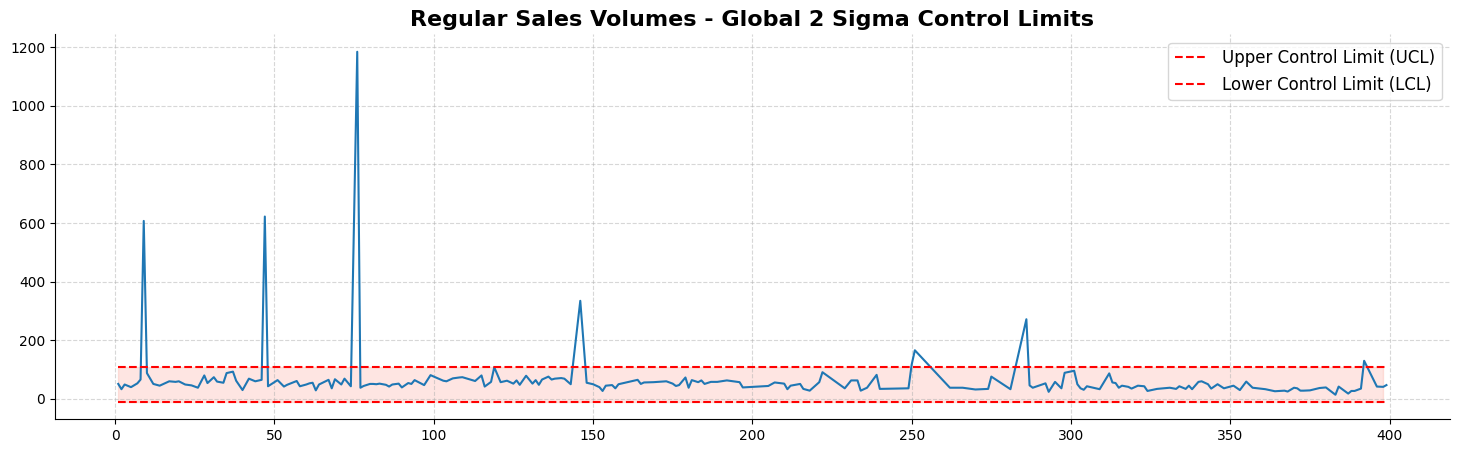

In [3]:
lower, upper = iqr(column = 'MOVE', k = 2, print_limits = True)

plt.figure(figsize = (18, 5))
plt.plot(data_modelling.WEEK, data_modelling.MOVE)
plt.hlines(y = upper, xmin = np.min(data_modelling.WEEK), xmax = np.max(data_modelling.WEEK), linestyles = '--', colors = 'red', label = 'Upper Control Limit (UCL)')
plt.hlines(y = lower, xmin = np.min(data_modelling.WEEK), xmax = np.max(data_modelling.WEEK), linestyles = '--', colors = 'red', label = 'Lower Control Limit (LCL)')
plt.title('Regular Sales Volumes - Global 2 Sigma Control Limits', fontsize = 16, fontweight = 'bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, ls = '--', alpha = 0.5)
plt.fill_between(x = range(np.min(data_modelling.WEEK), np.max(data_modelling.WEEK)), y1 = lower, y2 = upper, color = 'salmon', alpha = 0.2)
plt.legend(fontsize = 12)

plt.savefig('/Users/nathandouieb/Desktop/FinalProjectV3/src/visualization/RegularSalesControlLimit.png')
plt.show()

### 2.1 Interpolation of new NaN values

In [4]:
# Dropping higthers points
data_modelling['MOVE'] = data_modelling['MOVE'].where(data_modelling['MOVE'] < upper)

# Interpolate
data_modelling['MOVE'] = data_modelling.MOVE.interpolate(method = 'linear')
data_modelling.tail(3)

,WEEK,PRICE,MOVE
307,396,1.69,41.0
309,398,1.67,40.0
310,399,1.69,46.0


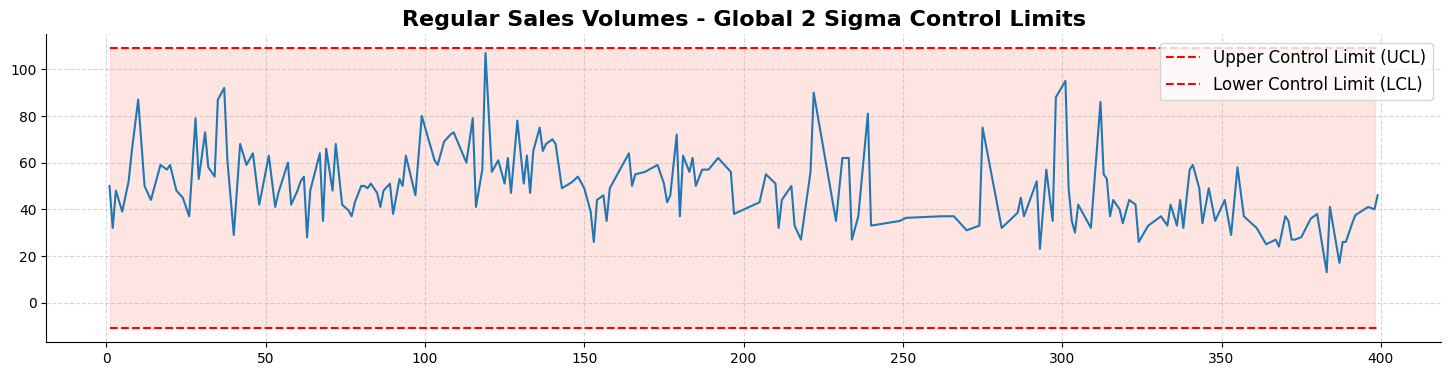

In [5]:
plt.figure(figsize = (18, 4))
plt.plot(data_modelling.WEEK, data_modelling.MOVE)
plt.hlines(y = upper, xmin = np.min(data_modelling.WEEK), xmax = np.max(data_modelling.WEEK), linestyles = '--', colors = 'red', label = 'Upper Control Limit (UCL)')
plt.hlines(y = lower, xmin = np.min(data_modelling.WEEK), xmax = np.max(data_modelling.WEEK), linestyles = '--', colors = 'red', label = 'Lower Control Limit (LCL)')
plt.title('Regular Sales Volumes - Global 2 Sigma Control Limits', fontsize = 16, fontweight = 'bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, ls = '--', alpha = 0.5)
plt.fill_between(x = range(np.min(data_modelling.WEEK), np.max(data_modelling.WEEK)), y1 = lower, y2 = upper, color = 'salmon', alpha = 0.2)
plt.legend(fontsize = 12, loc = 'upper right')

plt.savefig('/Users/nathandouieb/Desktop/FinalProjectV3/src/visualization/RegularSalesCleaned.png')
plt.show()

### 2.2 Algorithms

**Simple Mooving Average (SMA)**

The **Simple Moving Average (SMA)** is a technique in time series analysis used to smooth out short-term fluctuations and highlight underlying trends. It operates by calculating the unweighted mean of a specified number of the most recent data points.

#### Mathematical Formula
Given a time series and a fixed window size $n$ (also known as the rolling window), the moving average at time $t$ is calculated as the sum of the last $n$ values divided by $n$:

$$SMA_t = \frac{1}{n} \sum_{i=0}^{n-1} x_{t-i}$$

Where:
* $x_{t-i}$ represents the data points within the current window.
* $n$ is the size of the moving window (the span).

**Important :** A larger window size ($n$) results in a smoother curve but introduces a greater lag relative to the original data, whereas a smaller window is more responsive to recent changes but less effective at noise reduction.

In [6]:
def mooving_average(series, window_size):
    forecast = []
    for i in range(window_size, len(series)):                        #  2 -> 201       
        forecast.append(series[i - window_size : i].mean())           # data_modelling.MOVE[0: 2].mean() -> week 3
    forecast = np.array(forecast)
    return forecast

WINDOW_SIZE = 8
mooving_avg = mooving_average(series = data_modelling['MOVE'], window_size = WINDOW_SIZE)

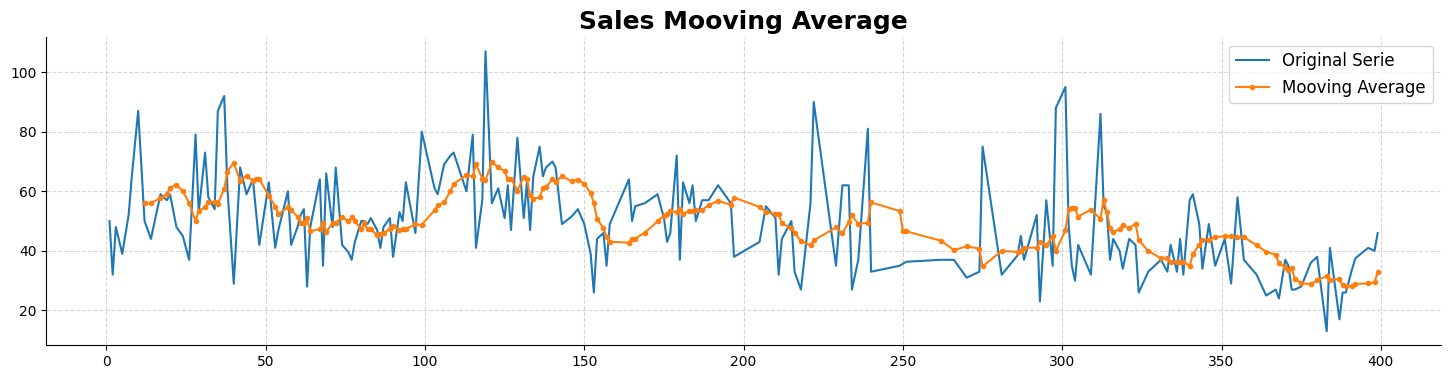

In [7]:
plt.figure(figsize = (18, 4))
plt.plot(data_modelling.WEEK, data_modelling.MOVE, label = 'Original Serie')
plt.plot(data_modelling.WEEK[WINDOW_SIZE:], mooving_avg, label = 'Mooving Average', marker = '.')
plt.title('Sales Mooving Average', fontsize = 18, fontweight = 'bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, ls = '--', alpha = 0.5)
plt.legend(fontsize = 12)

plt.savefig('/Users/nathandouieb/Desktop/FinalProjectV3/src/visualization/SalesMoovingAverage.png')
plt.show()

**Exponential Weighted Moving Average (EWM)**

The **Exponential Weighted Moving Average (EWM)** is an improvement over the simple moving average that applies weighting factors which decrease exponentially. Unlike the SMA, which weighs past observations equally, **EWM assigns greater importance to more recent data points**, making it more responsive to new information and trends.

The EWM is calculated recursively. For a series $x_t$, the value $y_t$ is defined as:

$$y_t = \alpha x_t + (1 - \alpha) y_{t-1}$$

Where:
* $x_t$ is the input value at time $t$.
* $y_{t-1}$ is the previous EWM value.
* $\alpha$ is the smoothing factor ($0 < \alpha \leq 1$).

**Important:** The parameter $\alpha$ determines the "memory" of the model. A higher $\alpha$ discounts older observations faster (closer to the current data), while a lower $\alpha$ produces a smoother curve. In pandas, this is often expressed via `span`, where $\alpha = 2 / (span + 1)$.

In [8]:
# apply EWM model
EWM = data_modelling['MOVE'].ewm(span = 52).mean()

**Hodrick-Prescott Filter (HP Filter)**

The **Hodrick-Prescott (HP) Filter** is a data smoothing technique widely used in macroeconomics. It separates a time series $y_t$ into two distinct components: a growth trend ($\tau_t$) and a cyclical component ($c_t$). The filter effectively removes short-term fluctuations to reveal the long-term trend.

The filter isolates the trend $\tau_t$ by minimizing the following loss function:

$$\min_{\tau} \left( \sum_{t=1}^T (y_t - \tau_t)^2 + \lambda \sum_{t=2}^{T-1} [(\tau_{t+1} - \tau_t) - (\tau_t - \tau_{t-1})]^2 \right)$$

Where:
* The first term penalizes the cyclical component (deviations from the trend).
* The second term penalizes variations in the growth rate of the trend.
* $\lambda$ (Lambda) is the smoothing parameter.

**Important:** The value of $\lambda$ controls the smoothness of the trend. Standard values are 1600 for quarterly data, 6.25 for annual data, and 14400 for monthly data.

In [9]:
from statsmodels.tsa.filters.hp_filter import hpfilter

cycle, trend_hp = hpfilter(x = data_modelling.MOVE, lamb = 14400)

**STL Decomposition (Seasonal-Trend using LOESS)**

**STL (Seasonal and Trend decomposition using Loess)** is a robust and versatile method for decomposing time series. Unlike classical decomposition methods, STL handles any type of seasonality (not just fixed periods) and is resilient to outliers. It uses LOESS (Locally Estimated Scatterplot Smoothing) to estimate the non-linear relationships.

#### Decomposition Structure
STL decomposes the time series $Y_t$ into three additive components:

$$Y_t = T_t + S_t + R_t$$

Where:
* $T_t$ is the **Trend** component (long-term progression).
* $S_t$ is the **Seasonal** component (repeating patterns).
* $R_t$ is the **Residual** (or Remainder) component (noise).

**Important:** STL allows the seasonal component to change over time (e.g., amplitude increasing) and provides control over the smoothness of the trend and seasonal cycles independently.

In [10]:
from statsmodels.tsa.seasonal import STL

stl = STL(endog = data_modelling.MOVE, period = 52)
res = stl.fit()
trend_stl = res.trend

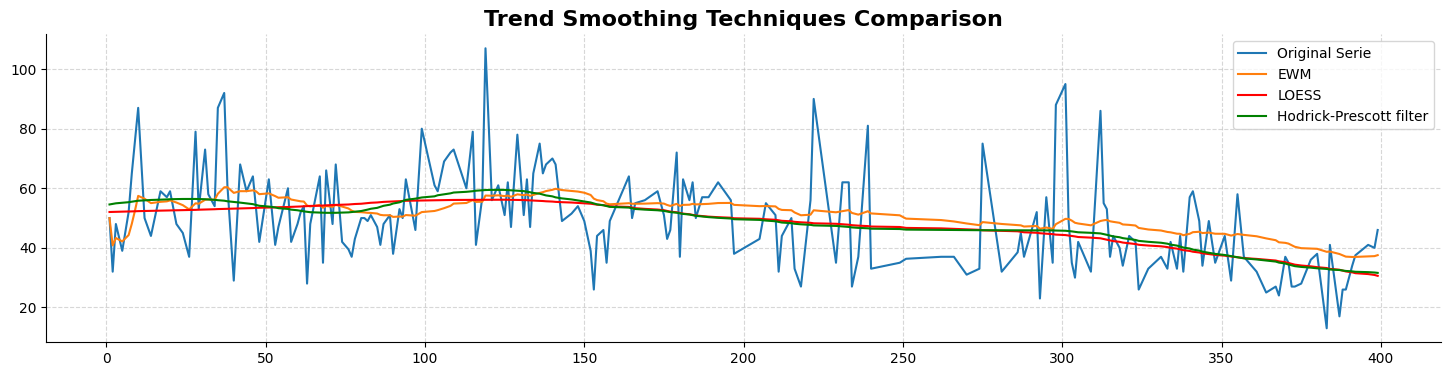

In [11]:
plt.figure(figsize = (18, 4))
plt.plot(data_modelling.WEEK, data_modelling.MOVE, label = 'Original Serie')
plt.plot(data_modelling.WEEK, EWM, label = 'EWM')
plt.plot(data_modelling.WEEK, trend_stl, label = 'LOESS', color = 'red')
plt.plot(data_modelling.WEEK, trend_hp, label = 'Hodrick-Prescott filter', color = 'green')
plt.title('Trend Smoothing Techniques Comparison', fontsize = 16, fontweight = 'bold')
plt.grid(True, ls = '--', alpha = 0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend()

plt.savefig('/Users/nathandouieb/Desktop/FinalProjectV3/src/visualization/AllSmothingPlot.png')
plt.show()

In [12]:
# MAE 
mae_ewm = (data_modelling['MOVE'] - EWM).abs().mean()
mae_stl = (data_modelling['MOVE'] - trend_stl).abs().mean()
mae_hp  = (data_modelling['MOVE'] - trend_hp).abs().mean()

print(f"MAE EWM (Exponentially Weighted Moving Average) : {mae_ewm:.4f}")
print(f"MAE STL (LOESS)              : {mae_stl:.4f}")
print(f"MAE HP  (Hodrick-Prescott)   : {mae_hp:.4f}")

MAE EWM (Exponentially Weighted Moving Average) : 10.9327
MAE STL (LOESS)              : 10.7953
MAE HP  (Hodrick-Prescott)   : 10.5149


### 3. Baseline for Price

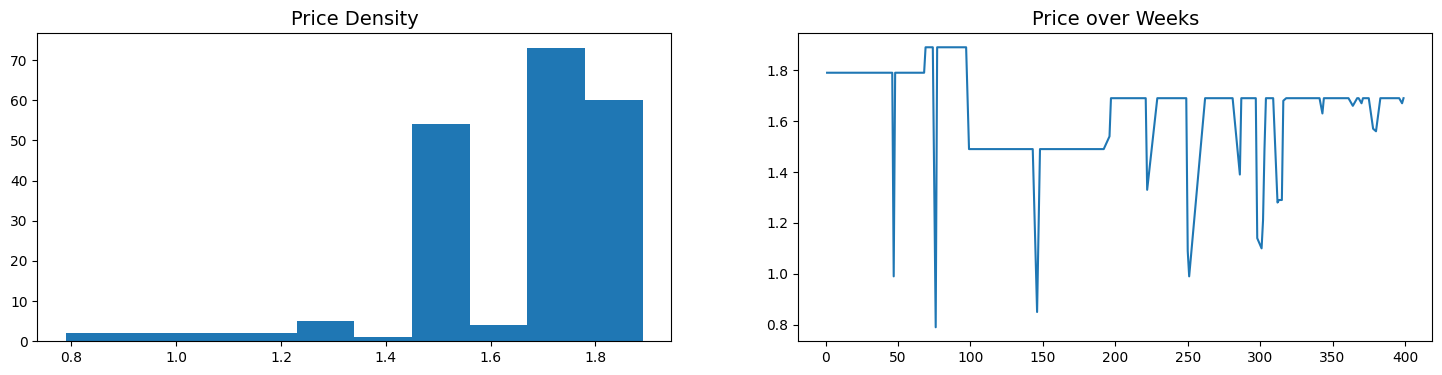

[1.79 0.99 1.89 0.79 1.49 0.85 1.54 1.69 1.33 1.09 1.39 1.14 1.1  1.21
 1.28 1.29 1.68 1.63 1.66 1.67 1.57 1.56]
Median Price: 1.69
Mean Price: 1.6369756097560972
STD Price: 0.1896996969287829


In [13]:
# Check Price Variability
fig, (ax1, ax2) = plt.subplots(ncols = 2, nrows = 1, figsize = (18, 4))
ax1.hist(data_modelling.PRICE)
ax1.set_title('Price Density', fontsize = 14)

ax2.plot(data_modelling.WEEK, data_modelling.PRICE)
ax2.set_title('Price over Weeks', fontsize = 14)

plt.savefig('/Users/nathandouieb/Desktop/FinalProjectV3/src/visualization/PriceVariability.png')
plt.show()

print(data_modelling.PRICE.unique())
print(f'Median Price: {np.median(data_modelling.PRICE)}')
print(f'Mean Price: {np.mean(data_modelling.PRICE)}')
print(f'STD Price: {np.std(data_modelling.PRICE)}')

Upper: 2.24
Lower: 1.04


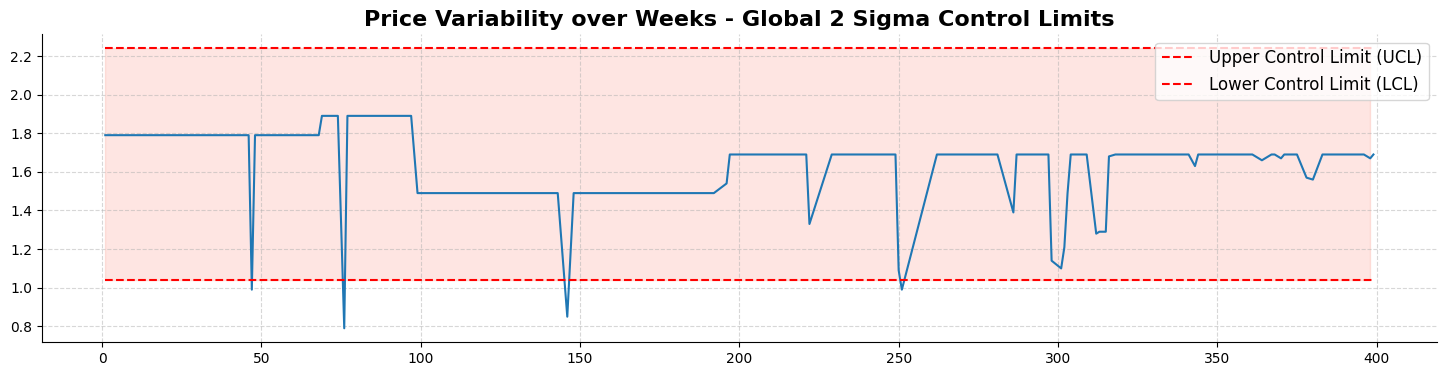

In [14]:
lower_price, upper_price = iqr(column = 'PRICE', k = 1.5, print_limits = True)

plt.figure(figsize = (18, 4))
plt.plot(data_modelling.WEEK, data_modelling.PRICE)
plt.hlines(y = upper_price, xmin = np.min(data_modelling.WEEK), xmax = np.max(data_modelling.WEEK), linestyles = '--', colors = 'red', label = 'Upper Control Limit (UCL)')
plt.hlines(y = lower_price, xmin = np.min(data_modelling.WEEK), xmax = np.max(data_modelling.WEEK), linestyles = '--', colors = 'red', label = 'Lower Control Limit (LCL)')
plt.title('Price Variability over Weeks - Global 2 Sigma Control Limits', fontsize = 16, fontweight = 'bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, ls = '--', alpha = 0.5)
plt.fill_between(x = range(np.min(data_modelling.WEEK), np.max(data_modelling.WEEK)), y1 = lower_price, y2 = upper_price, color = 'salmon', alpha = 0.2)
plt.legend(fontsize = 12, loc = 'upper right')

plt.savefig('/Users/nathandouieb/Desktop/FinalProjectV3/src/visualization/PriceVariability2.png')
plt.show()

In [15]:
# Dropping higthers points
data_modelling['PRICE'] = data_modelling['PRICE'].where(data_modelling['PRICE'] > lower_price)

# Interpolate using linear method
data_modelling['PRICE'] = data_modelling.PRICE.interpolate(method = 'linear')
data_modelling.head(3)

,WEEK,PRICE,MOVE
0,1,1.79,50.0
1,2,1.79,32.0
2,3,1.79,48.0


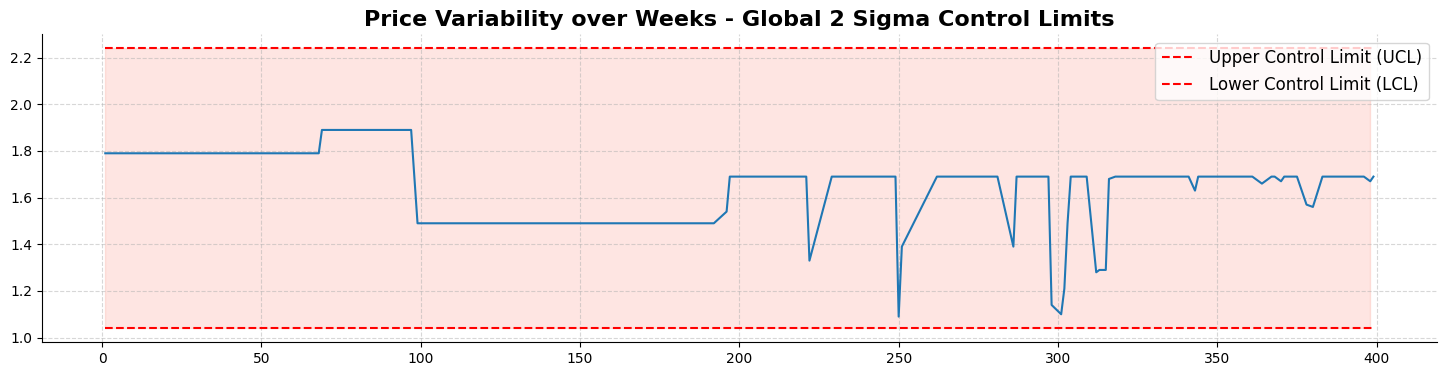

In [16]:
plt.figure(figsize = (18, 4))
plt.plot(data_modelling.WEEK, data_modelling.PRICE)
plt.hlines(y = upper_price, xmin = np.min(data_modelling.WEEK), xmax = np.max(data_modelling.WEEK), linestyles = '--', colors = 'red', label = 'Upper Control Limit (UCL)')
plt.hlines(y = lower_price, xmin = np.min(data_modelling.WEEK), xmax = np.max(data_modelling.WEEK), linestyles = '--', colors = 'red', label = 'Lower Control Limit (LCL)')
plt.title('Price Variability over Weeks - Global 2 Sigma Control Limits', fontsize = 16, fontweight = 'bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, ls = '--', alpha = 0.5)
plt.fill_between(x = range(np.min(data_modelling.WEEK), np.max(data_modelling.WEEK)), y1 = lower_price, y2 = upper_price, color = 'salmon', alpha = 0.2)
plt.legend(fontsize = 12, loc = 'upper right')

plt.savefig('/Users/nathandouieb/Desktop/FinalProjectV3/src/visualization/PriceVariabilityCleaned.png')
plt.show()

In [17]:
# Algorithms
# Mooving Average
WINDOW_SIZE_PRICE = 4
mooving_avg_price = mooving_average(series = data_modelling['PRICE'], window_size = WINDOW_SIZE_PRICE)

# HP 
cycle_price, trend_hp_price = hpfilter(x = data_modelling['PRICE'], lamb = 14400)

# STL
stl_price = STL(endog = data_modelling.PRICE, period = 52).fit()
trend_stl_price = stl_price.trend

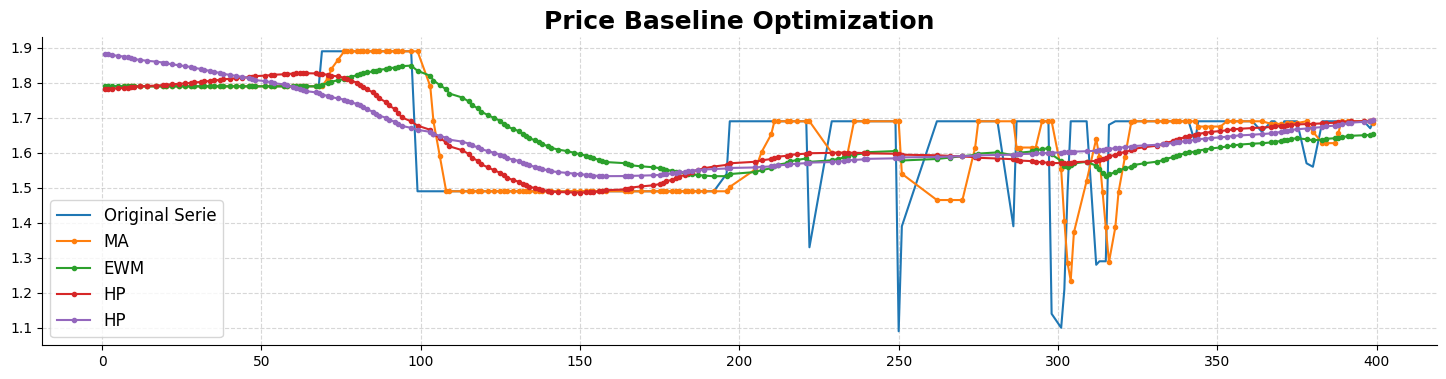

In [18]:
plt.figure(figsize = (18, 4))
plt.plot(data_modelling.WEEK, data_modelling.PRICE, label = 'Original Serie')
plt.plot(data_modelling.WEEK[WINDOW_SIZE_PRICE:], mooving_avg_price, label = 'MA', marker = '.')
plt.plot(data_modelling.WEEK, data_modelling.PRICE.ewm(span = 52).mean(), label = 'EWM', marker = '.')
plt.plot(data_modelling.WEEK, trend_hp_price, label = 'HP', marker = '.')
plt.plot(data_modelling.WEEK, trend_stl_price, label = 'HP', marker = '.')
plt.title('Price Baseline Optimization', fontsize = 18, fontweight = 'bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, ls = '--', alpha = 0.5)
plt.legend(fontsize = 12)

plt.savefig('/Users/nathandouieb/Desktop/FinalProjectV3/src/visualization/AllSmothingPrice.png')
plt.show()

In [19]:
# MAE 
mae_ewm_price = (data_modelling['PRICE'] - data_modelling.PRICE.ewm(span = 52).mean()).abs().mean()
mae_stl_price = (data_modelling['PRICE'] - trend_stl_price).abs().mean()
mae_hp_price  = (data_modelling['PRICE'] - trend_hp_price).abs().mean()

print(f"MAE EWM (Exponentially Weighted Moving Average) : {mae_ewm_price:.4f}")
print(f"MAE STL (LOESS)              : {mae_stl_price:.4f}")
print(f"MAE HP  (Hodrick-Prescott)   : {mae_hp_price:.4f}")

MAE EWM (Exponentially Weighted Moving Average) : 0.0940
MAE STL (LOESS)              : 0.0914
MAE HP  (Hodrick-Prescott)   : 0.0698


In [20]:
# Save models
import joblib

params: dict = {'HP_Filter_Sales': trend_hp.values, 'HP_Filter_Price': trend_hp_price.values}
PATH: str = '/Users/nathandouieb/Desktop/FinalProjectV3/data/processed/params.pkl'
PATH_DATA: str = '/Users/nathandouieb/Desktop/FinalProjectV3/data/processed/data_model.xlsx'

joblib.dump(params, PATH)
print('Parameters Downladed.')

data_modelling.to_excel(PATH_DATA)
print('Excel Downladed.')

Parameters Downladed.
Excel Downladed.
